In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import ROOT
import itertools

from plotting_helpers import *

plt.style.use('root')

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load both dataframes
df_all_sf4 = pd.read_parquet("data/recoTri-Run6640-SF4.parquet").query(
    "n_lines == 3"
)
df_gal_sf4 = pd.read_parquet("data/recoTri-Gallery-SF4.parquet").query(
    "n_lines == 3"
)

features = [
    "scifi_nhits",
    "sum_hit_weight_density",
    "sum_qdc",
    "max_scifi_nhits_per_plane",
    "max_scifi_qdc_per_plane",
]

# Set up a grid of subplots
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()  # Flatten to easily loop over them

for i, col in enumerate(features):
    ax = axes[i]

    # Plot 'all' dataframe density
    sns.kdeplot(
        data=df_all_sf4,
        x=col,
        ax=ax,
        label="All SF4",
        fill=True,
        alpha=0.2,
        log_scale=True,
    )

    # Plot 'gallery' dataframe density
    sns.kdeplot(
        data=df_gal_sf4,
        x=col,
        ax=ax,
        label="Gallery SF4",
        fill=True,
        alpha=0.2,
        log_scale=True,
    )

    ax.set_title(f"Density of {col}")
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)

# Remove the unused 6th subplot grid cell
if len(axes) > len(features):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

array([[<Axes: title={'center': 'scifi_nhits'}>,
        <Axes: title={'center': 'sum_hit_weight_density'}>],
       [<Axes: title={'center': 'sum_qdc'}>,
        <Axes: title={'center': 'max_scifi_nhits_per_plane'}>],
       [<Axes: title={'center': 'max_scifi_qdc_per_plane'}>, <Axes: >]],
      dtype=object)

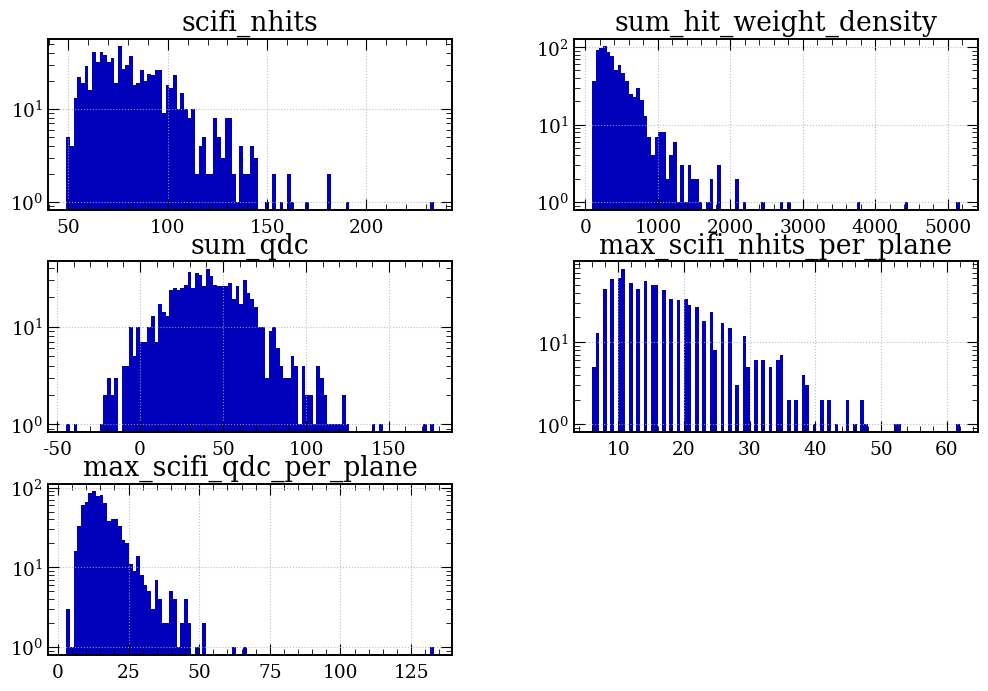

In [ ]:
# df_all_sf4 = pd.read_parquet("data/recoTri-Run6640-SF4.parquet").query("n_tracks == 3")
df_gal_sf4 = pd.read_parquet("data/recoTri-Gallery-SF4.parquet").query("n_tracks == 3")
df_gal_sf4[['scifi_nhits', 'sum_hit_weight_density', 'sum_qdc',
       'max_scifi_nhits_per_plane', 'max_scifi_qdc_per_plane']].hist(bins=100, figsize=(12, 8), log=True)

In [ ]:
def get_vtx(df):
    df["z_vtx_xz_12"] = (df["xz_c2"] - df["xz_c1"]) / (df["xz_m1"] - df["xz_m2"])
    df["z_vtx_xz_13"] = (df["xz_c3"] - df["xz_c1"]) / (df["xz_m1"] - df["xz_m3"])
    df["z_vtx_xz_23"] = (df["xz_c3"] - df["xz_c2"]) / (df["xz_m2"] - df["xz_m3"])
    df["z_vtx_yz_12"] = (df["yz_c2"] - df["yz_c1"]) / (df["yz_m1"] - df["yz_m2"])
    df["z_vtx_yz_13"] = (df["yz_c3"] - df["yz_c1"]) / (df["yz_m1"] - df["yz_m3"])
    df["z_vtx_yz_23"] = (df["yz_c3"] - df["yz_c2"]) / (df["yz_m2"] - df["yz_m3"])
    return df

# df_all_sf4 = get_vtx(df_all_sf4)
df_gal_sf4 = get_vtx(df_gal_sf4)

In [ ]:
df_gal_sf4.query("run==6640 and n_lines==3")

In [ ]:
def applyCutsToGallery(df,
    sum_hit_density_w_sf = 2500,
    sum_qdc_sf = 200
):
    df = df[df["sum_hit_weight_density"] <= sum_hit_density_w_sf]
    df = df[df["sum_qdc"] <= sum_qdc_sf]
    return df

def get_nonNan(df):
    return df.dropna(subset=["xz_m3", "yz_m3"])

In [ ]:
# df_all_sf4 = get_nonNan(df_all_sf4)
# df_gal_sf4 = applyCutsToGallery(get_nonNan(df_gal_sf4))
df_gal_sf4 = df_gal_sf4.query("run==6640 and n_lines==3")
df_all_sf4 = df_all_sf4.query("run==6640 and n_lines==3")

print(len(df_all_sf4), len(df_gal_sf4))

In [20]:
df_all_sf4.columns

Index(['run', 'event_number', 'n_lines', 'xz_m1', 'xz_c1', 'xz_m2', 'xz_c2',
       'xz_m3', 'xz_c3', 'yz_m1', 'yz_c1', 'yz_m2', 'yz_c2', 'yz_m3', 'yz_c3',
       'scifi_nhits', 'sum_hit_weight_density', 'sum_qdc',
       'max_scifi_nhits_per_plane', 'max_scifi_qdc_per_plane'],
      dtype='object')

In [28]:
df_gal_sf4_f['max_scifi_qdc_per_plane'].max()

39.70999988913536

In [37]:
max_sum_qdc = 150
max_qdc_per_sf_plane = 40
max_hdw = 3000
max_sf_nhits=200
max_sf_nhits_per_plane = 55

df_all_sf4_f2 = df_all_sf4_f.query(f"max_scifi_nhits_per_plane < {max_sf_nhits_per_plane}")
df_gal_sf4_f2 = df_gal_sf4_f.query(f"max_scifi_nhits_per_plane < {max_sf_nhits_per_plane}")

df_all_sf4_f3 = df_all_sf4_f2.query(f"scifi_nhits < {max_sf_nhits}")
df_gal_sf4_f3 = df_gal_sf4_f2.query(f"scifi_nhits < {max_sf_nhits}")

df_all_sf4_f4 = df_all_sf4_f3.query(f"sum_hit_weight_density < {max_hdw}")
df_gal_sf4_f4 = df_gal_sf4_f3.query(f"sum_hit_weight_density < {max_hdw}")

df_all_sf4_f5 = df_all_sf4_f4.query(f"sum_qdc < {max_sum_qdc}")
df_gal_sf4_f5 = df_gal_sf4_f4.query(f"sum_qdc < {max_sum_qdc}")

df_all_sf4_f6 = df_all_sf4_f5.query(f"max_scifi_qdc_per_plane < {max_qdc_per_sf_plane}")
df_gal_sf4_f6 = df_gal_sf4_f5.query(f"max_scifi_qdc_per_plane < {max_qdc_per_sf_plane}")




print(len(df_all_sf4_f2), len(df_gal_sf4_f2))
print(len(df_all_sf4_f3), len(df_gal_sf4_f3))
print(len(df_all_sf4_f4), len(df_gal_sf4_f4))
print(len(df_all_sf4_f5), len(df_gal_sf4_f5))
print(len(df_all_sf4_f6), len(df_gal_sf4_f6))

192 65
150 65
146 65
145 65
137 65


In [ ]:
xy = {"x": (-42.3, -10.7), "y": (17.7, 49.3)}
z_plane  = 320
z_range = (290, 560)
dist = 0.225


print(len(df_all_sf4), len(df_gal_sf4.query("run==6640")))

def filter_by_track_separation(df, Z_plane=320, dist=0.1, both_proj=False):
    x1, x2, x3 = df['xz_m1']*Z_plane + df['xz_c1'], df['xz_m2']*Z_plane + df['xz_c2'], df['xz_m3']*Z_plane + df['xz_c3']
    y1, y2, y3 = df['yz_m1']*Z_plane + df['yz_c1'], df['yz_m2']*Z_plane + df['yz_c2'], df['yz_m3']*Z_plane + df['yz_c3']
    
    x = [x1, x2, x3]
    y = [y1, y2, y3]

    xz_min_dist = pd.concat([abs(x[i] - x[j]) for i, j in itertools.combinations(range(3), 2)], axis=1).min(axis=1).fillna(np.inf)
    yz_min_dist = pd.concat([abs(y[i] - y[j]) for i, j in itertools.combinations(range(3), 2)], axis=1).min(axis=1).fillna(np.inf)

    has_3_xz = x1.notna() & x2.notna() & x3.notna()
    has_3_yz = y1.notna() & y2.notna() & y3.notna()
    valid_3_lines = has_3_xz | has_3_yz
    
    xz_separated = xz_min_dist > dist
    yz_separated = yz_min_dist > dist
    
    if both_proj:
        keep_mask = valid_3_lines & xz_separated & yz_separated
    else:
        keep_mask = (has_3_xz & xz_separated) | (has_3_yz & yz_separated)

    return df[keep_mask]

def filter_by_fiducial_area(df, x_range=(-42, -11), y_range=(18, 49), Z_plane=320, both_proj=False):
    x_min, x_max = x_range
    y_min, y_max = y_range

    x_crossings = pd.DataFrame(
        {
            "l1": df["xz_m1"] * Z_plane + df["xz_c1"],
            "l2": df["xz_m2"] * Z_plane + df["xz_c2"],
            "l3": df["xz_m3"] * Z_plane + df["xz_c3"],
        },
        index=df.index,
    )

    y_crossings = pd.DataFrame(
        {
            "l1": df["yz_m1"] * Z_plane + df["yz_c1"],
            "l2": df["yz_m2"] * Z_plane + df["yz_c2"],
            "l3": df["yz_m3"] * Z_plane + df["yz_c3"],
        },
        index=df.index,
    )

    xz_inside = (
        ((x_crossings >= x_min) & (x_crossings <= x_max)) | x_crossings.isna()
    ).all(axis=1)
    
    yz_inside = (
        ((y_crossings >= y_min) & (y_crossings <= y_max)) | y_crossings.isna()
    ).all(axis=1)

    xz_has_tracks = x_crossings.notna().any(axis=1)
    yz_has_tracks = y_crossings.notna().any(axis=1)

    xz_pass = xz_inside & xz_has_tracks
    yz_pass = yz_inside & yz_has_tracks

    if both_proj:
        keep_mask = xz_pass & yz_pass
    else:
        keep_mask = xz_pass | yz_pass

    return df[keep_mask]

def filter_by_collinearity(df, z_range=(260, 580), both_proj=False):
    df = get_vtx(df)

    xz_vtx_cols = ['z_vtx_xz_12', 'z_vtx_xz_13', 'z_vtx_xz_23']
    yz_vtx_cols = ['z_vtx_yz_12', 'z_vtx_yz_13', 'z_vtx_yz_23']

    has_3_xz = df['xz_m3'].notna()
    has_3_yz = df['yz_m3'].notna()
    
    df_filtered = df[has_3_xz | has_3_yz].copy()
    z_min, z_max = z_range

    xz_collinear = (
        (df_filtered[xz_vtx_cols].fillna(np.inf) < z_min) | 
        (df_filtered[xz_vtx_cols].fillna(np.inf) > z_max)
    ).all(axis=1)
    
    yz_collinear = (
        (df_filtered[yz_vtx_cols].fillna(np.inf) < z_min) | 
        (df_filtered[yz_vtx_cols].fillna(np.inf) > z_max)
    ).all(axis=1)
    
    xz_3_line_pass = has_3_xz.loc[df_filtered.index] & xz_collinear
    yz_3_line_pass = has_3_yz.loc[df_filtered.index] & yz_collinear
    
    if both_proj:
        keep_mask = xz_collinear & yz_collinear
    else:
        keep_mask = xz_3_line_pass | yz_3_line_pass
        
    return df_filtered[keep_mask]


df_all_sf4_f = filter_by_track_separation(df_all_sf4.query("run==6640"), dist=dist, both_proj=True)
df_all_sf4_f = filter_by_fiducial_area(df_all_sf4_f, Z_plane=z_plane, x_range=xy["x"], y_range=xy["y"], both_proj=True)
df_all_sf4_f = filter_by_collinearity(df_all_sf4_f, z_range=z_range, both_proj=False)
    
df_gal_sf4_f = filter_by_track_separation(df_gal_sf4.query("run==6640"), dist=dist, both_proj=True)
df_gal_sf4_f = filter_by_fiducial_area(df_gal_sf4_f, Z_plane=z_plane, x_range=xy["x"], y_range=xy["y"], both_proj=True)
df_gal_sf4_f = filter_by_collinearity(df_gal_sf4_f, z_range=z_range, both_proj=False)

print(len(df_all_sf4_f), len(df_gal_sf4_f), "    |    ", len(df_all_sf4), len(df_gal_sf4))

In [ ]:
df_gal_inseperable = df_gal_sf4[~df_gal_sf4["event_number"].isin(df_gal_sf4_f["event_number"])]
df_gal_inseperable

In [ ]:
run_number = 6640
event_number = 34929307



f_num = event_number // 1000000
j_num = (event_number % 1000000) // 100000
batch_num = 0

# path = f"/eos/user/i/idioniso/tridents/run_006640-15Jun26/sf4/recoTri_{run_number}_f{f_num:04d}_j{j_num:02d}_{batch_num}.root"
path = f"/eos/user/i/idioniso/tridents/gallery-15Jun26/sf4/backup/recoTri_{run_number}_f{f_num:04d}.root"
f = ROOT.TFile.Open(path)
canvas = f.Get(f"c_Run{run_number}_{event_number}")

plot_trident_event(canvas,
    figsize=(12, 10), output=None,
    xlim=(-60, 0), ylim=(0, 60), zlim=(260, 380),
    conf={
        "trk_sep": {"z": z_plane, "tol": dist},
        'fiducial_area': {"z": 320, "x_range": xy["x"], "y_range": xy["y"], "vline": True, "hlines": False},
    }
)

In [ ]:
cols = df_all_sf4_f.columns.tolist()

merged = pd.merge(df_all_sf4_f, df_gal_sf4_f, on=cols, how='outer', indicator=True)

df0 =  merged[merged['_merge'] == 'both'].drop(columns=['_merge'])
df_all_only = merged[merged['_merge'] == 'left_only'].drop(columns=['_merge'])
df_gal_only = merged[merged['_merge'] == 'right_only'].drop(columns=['_merge'])

df_all_only

In [ ]:
print(len(df_all_sf4), len(df_gal_sf4.query("run==6640")))
# print(len(df_gal_sf4.query("run==6640")))

In [ ]:
def plot_cols(*dfs, labels=None, bins=80, density=False, figsize=(15, 10),
              columns_to_plot=[
                  'scifi_nhits', 'sum_hit_weight_density', 'sum_qdc',
                  'max_scifi_nhits_per_plane', 'max_scifi_qdc_per_plane'
              ]):
    
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=figsize)
    axes = axes.flatten()

    for i, col in enumerate(columns_to_plot):
        ax = axes[i]
        
        cleaned_datasets = []
        for df in dfs:
            if col in df.columns:
                clean_data = df[col].dropna()
                clean_data = clean_data[~clean_data.isin([float('inf'), float('-inf')])]
                clean_data = clean_data[clean_data > 0]
                cleaned_datasets.append(clean_data)
            else:
                cleaned_datasets.append(None)

        valid_data = [d for d in cleaned_datasets if d is not None and not d.empty]
        if not valid_data:
            ax.set_title(f"No Data for {col}")
            continue
            
        global_min = min(d.min() for d in valid_data)
        global_max = max(d.max() for d in valid_data)


        bin_edges = np.logspace(np.log10(global_min), np.log10(global_max), num=bins + 1)
        
        for j, clean_data in enumerate(cleaned_datasets):
            if clean_data is not None:
                lbl = labels[j] if labels and j < len(labels) else f"DF {j+1}"
                
                ax.hist(clean_data, bins=bin_edges, alpha=0.5, label=lbl, density=density)
        
        ax.set_title(f"Distribution of {col}", fontsize=12, fontweight='bold')
        ax.set_xlabel(f"{col}", fontsize=10)
        # ax.set_xscale('log')
        ax.set_yscale('log')
        
        y_label = "Density" if density else "Counts"
        ax.set_ylabel(y_label, fontsize=10)
        
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend()

    # Hide any unused subplots (e.g., if you have 5 columns but 6 subplots)
    for j in range(len(columns_to_plot), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
    # plt.savefig("./pdf/4_cutflow.pdf")
    # plt.savefig("./png/4_cutflow.png")

plot_cols(df_gal_sf4, df_all_sf4, labels=["Gallery", "All events"], bins=50, density=True,
    columns_to_plot=['z_vtx_xz_12',
       'z_vtx_xz_13', 'z_vtx_xz_23', 'z_vtx_yz_12', 'z_vtx_yz_13',
       'z_vtx_yz_23']      
    )

In [ ]:
df_gal_sf4.columns

In [ ]:
import math

exclude_cols = ['run', 'event_number', 'n_lines', 'xz_m1', 'xz_c1', 'xz_m2',
                'xz_c2', 'xz_m3', 'xz_c3', 'yz_m1', 'yz_c1', 'yz_m2', 'yz_c2',
                'yz_m3', 'yz_c3', 'z_vtx_xz_12', 'z_vtx_xz_13', 'z_vtx_xz_23',
                'z_vtx_yz_12', 'z_vtx_yz_13', 'z_vtx_yz_23']

# Ensure you are referencing the correct dataframe for columns
numerical_cols = [col for col in df_gal_sf4.columns if col not in exclude_cols]

num_plots = len(numerical_cols)
num_cols = 2
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
axes = axes.flatten()

# Combine into a single loop to plot both datasets on the same axis simultaneously
for i, col in enumerate(numerical_cols):
    ax = axes[i]
    
    # Plot Dataset 1 (Gal)
    sns.histplot(
        data=df_gal_sf4_f, 
        x=col, 
        ax=ax, 
        color='royalblue', 
        alpha=0.5,          
        label='Dataset 1 (Gal)',
        element='step',      
        stat="density"
    )
    
    # Plot Dataset 2 (All)
    sns.histplot(
        data=df_all_sf4_f, 
        x=col, 
        ax=ax, 
        color='crimson', 
        alpha=0.5,          
        label='Dataset 2 (All)',
        element='step',      
        stat="density"
    )
    
    # Formatting adjustments
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Density') # Changed from 'Counts' because density=True
    ax.legend()              # CRITICAL: This makes your labels actually appear

    ax.set_yscale('log')  # Set y-axis to logarithmic scale

# Hide any unused subplots safely
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# z_vtx_min = 270
# z_vtx_max = 600

# xz_columns = ["z_vtx_xz_12", "z_vtx_xz_13", "z_vtx_xz_23"]
# yz_columns = ["z_vtx_yz_12", "z_vtx_yz_13", "z_vtx_yz_23"]

# mask = ((df[xz_columns] >= z_vtx_min) & (df[xz_columns] <= z_vtx_max)).any(axis=1)
# df = df[mask]

In [ ]:
print(len(df_all_sf4), len(df_gal_sf4.query("run==6640")))

In [ ]:
df = df_all_only.copy()

runs = [6640]
events = df["event_number"].to_list()
f_nums = [ev // 1000000 for ev in events]
j_nums = [(ev % 1000000) // 100000 for ev in events]
batch_nums = [0, 1]


for run in set(runs):
    df_run = df[df['run'] == run].copy()
    df_run['f_num'] = df_run['event_number'] // 1000000
    df_run['j_num'] = (df_run['event_number'] % 1000000) // 100000

    out_dir = Path(f"/afs/cern.ch/work/i/idioniso/sndTridentCrossCheck/notebooks/events/all_only/two_proj_png/")
    out_dir.mkdir(parents=True, exist_ok=True)
    

    for (f_num, j_num), group in df_run.groupby(['f_num', 'j_num']):

        for batch_num in batch_nums:
            path = f"/eos/user/i/idioniso/tridents/run_{run:06d}-15Jun26/sf4/recoTri_{run}_f{f_num:04d}_j{j_num:02d}_{batch_num}.root"
            # path = f"/eos/user/i/idioniso/tridents/gallery-15Jun26/recoTri_{run}_f{f_num:04d}_0.root"
            
            if not os.path.exists(path):
                print(f"  [!] Missing file: {path}")
                continue

            f = ROOT.TFile.Open(path)
            if not f or f.IsZombie():
                continue

            for event in group['event_number']:
                canv_name = f"c_Run{run}_{event}"
                canv = f.Get(canv_name)
                
                if not canv:
                    continue
                    
                output_file = out_dir / f"trident_display_{event}.png"
        
                plot_trident_event(canv,
                    figsize=(12, 10), output=str(output_file),
                    xlim=(-60, 0), ylim=(0, 60), zlim=(260, 380),
                    conf={
                        "trk_sep": {"z": z_plane, "tol": dist},
                        'fiducial_area': {"z": 320, "x_range": xy["x"], "y_range": xy["y"], "vline": True, "hlines": False},
                    }
                )
                plt.close()
                print(f"  [+] Saved: Run {run} Event {event}")

            f.Close()

In [ ]:
recoTri_6640_f0274_j08_1.root